In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import seaborn as sns

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

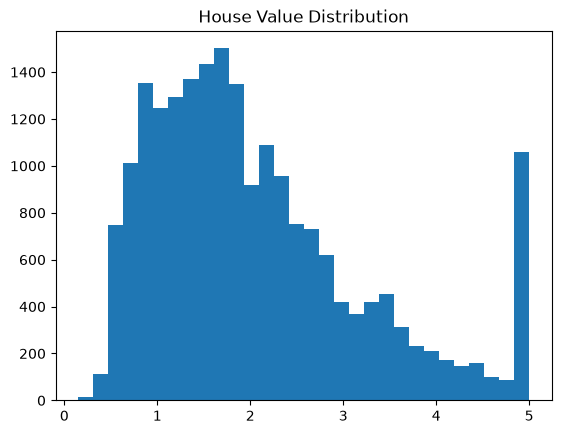

In [4]:
plt.figure()
plt.hist(df['MedHouseVal'], bins=30)
plt.title("House Value Distribution")
plt.show()

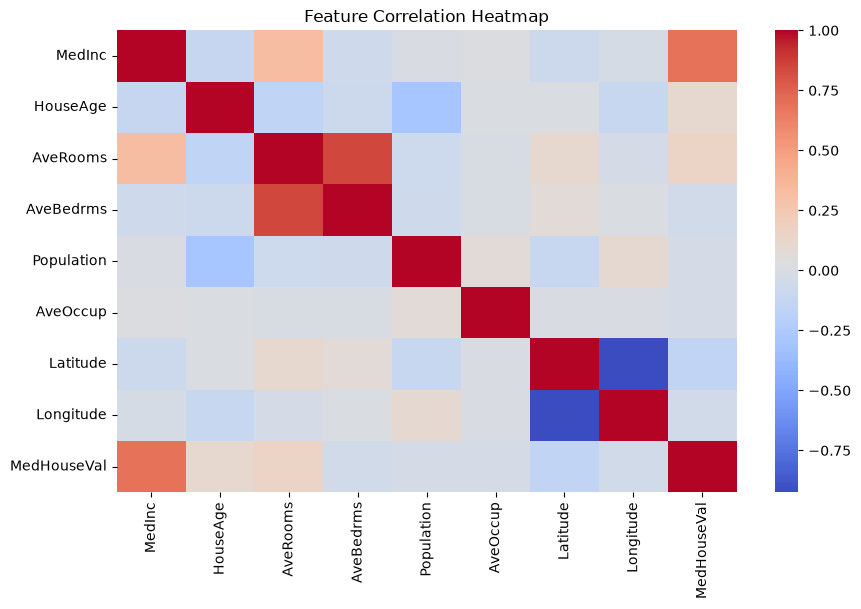

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
baseline_pred = np.full_like(y_test, y_train.mean())

mae_base = mean_absolute_error(y_test, baseline_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, baseline_pred))
r2_base = r2_score(y_test, baseline_pred)

print("BASELINE RESULTS")
print(mae_base, rmse_base, r2_base)

BASELINE RESULTS
0.9060685490007149 1.1448563543099792 -0.00021908714592466794


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, lr_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))
r2_lr = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print(mae_lr, rmse_lr, r2_lr)

Linear Regression Results
0.5332001304956565 0.7455813830127764 0.5757877060324508


In [11]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

print("Random Forest Results")
print(mae_rf, rmse_rf, r2_rf)

Random Forest Results
0.32773108008720936 0.5059859946022769 0.8046244867176197


In [12]:
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "MAE": [mae_base, mae_lr, mae_rf],
    "RMSE": [rmse_base, rmse_lr, rmse_rf],
    "R2": [r2_base, r2_lr, r2_rf]
})

results

,Model,MAE,RMSE,R2
0,Baseline,0.906069,1.144856,-0.000219
1,Linear Regression,0.533200,0.745581,0.575788
2,Random Forest,0.327731,0.505986,0.804624


In [13]:
cv_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring="r2")
cv_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2")

print("Linear Regression CV:", cv_lr.mean())
print("Random Forest CV:", cv_rf.mean())

Linear Regression CV: 0.6114839952560992
Random Forest CV: 0.8044053691692102


In [14]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
best_model = grid.best_estimator_

Best Params: {'max_depth': None, 'n_estimators': 200}


In [15]:
final_pred = best_model.predict(X_test)

mae_final = mean_absolute_error(y_test, final_pred)
rmse_final = np.sqrt(mean_squared_error(y_test, final_pred))
r2_final = r2_score(y_test, final_pred)

print(mae_final, rmse_final, r2_final)

0.32679252083333354 0.5042884756378109 0.8059332079649745


In [16]:
log = pd.DataFrame({
    "Experiment": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Score (R2)": [
        r2_base,
        r2_lr,
        r2_rf,
        r2_final
    ]
})

log

,Experiment,Score (R2)
0,Baseline,-0.000219
1,Linear Regression,0.575788
2,Random Forest,0.804624
3,Tuned Random Forest,0.805933


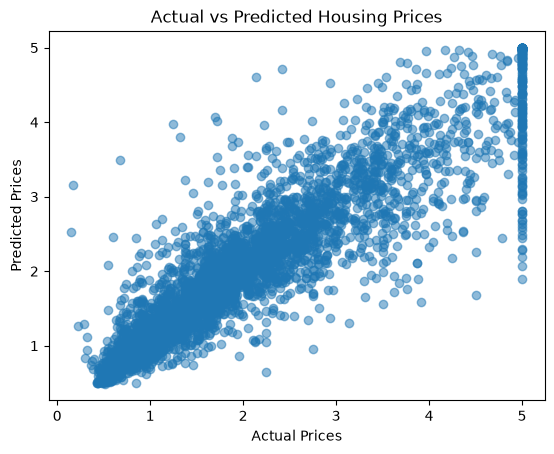

In [17]:
plt.figure()
plt.scatter(y_test, final_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.show()

In [18]:
import joblib

joblib.dump(best_model, "california_housing_model.pkl")
print("Model saved!")

Model saved!
